In [15]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_inventor_disambiguated.tsv
/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_assignee_disambiguated.tsv
/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_patent.tsv
/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_patent_abstract.tsv
/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_location_disambiguated.tsv


In [28]:
!pip install pandas sqlalchemy

In [5]:
import pandas as pd
import sqlite3
import json

In [6]:
# File paths
inventor_path = "/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_inventor_disambiguated.tsv"
assignee_path = "/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_assignee_disambiguated.tsv"
patent_path = "/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_patent.tsv"
abstract_path = "/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_patent_abstract.tsv"
location_path = "/kaggle/input/datasets/ainembabazibritah/patent-pipeline/g_location_disambiguated.tsv"

# Read files
inventors = pd.read_csv(inventor_path, sep="\t", low_memory=False)
assignees = pd.read_csv(assignee_path, sep="\t", low_memory=False)
patents = pd.read_csv(patent_path, sep="\t", low_memory=False)
abstracts = pd.read_csv(abstract_path, sep="\t", low_memory=False)
locations = pd.read_csv(location_path, sep="\t", low_memory=False)

print("Loaded successfully")

Loaded successfully


In [7]:
print("PATENTS")
print(patents.columns)

print("\nINVENTORS")
print(inventors.columns)

print("\nASSIGNEES")
print(assignees.columns)

print("\nABSTRACTS")
print(abstracts.columns)

print("\nLOCATIONS")
print(locations.columns)

PATENTS
Index(['patent_id', 'patent_type', 'patent_date', 'patent_title', 'wipo_kind',
       'num_claims', 'withdrawn', 'filename'],
      dtype='object')

INVENTORS
Index(['patent_id', 'inventor_sequence', 'inventor_id',
       'disambig_inventor_name_first', 'disambig_inventor_name_last',
       'gender_code', 'location_id'],
      dtype='object')

ASSIGNEES
Index(['patent_id', 'assignee_sequence', 'assignee_id',
       'disambig_assignee_individual_name_first',
       'disambig_assignee_individual_name_last',
       'disambig_assignee_organization', 'assignee_type', 'location_id'],
      dtype='object')

ABSTRACTS
Index(['patent_id', 'patent_abstract'], dtype='object')

LOCATIONS
Index(['location_id', 'disambig_city', 'disambig_state', 'disambig_country',
       'latitude', 'longitude', 'county', 'state_fips', 'county_fips'],
      dtype='object')


In [8]:
# ===============================
# CLEAN PATENTS TABLE
# ===============================

clean_patents = patents[[
    'patent_id',
    'patent_title',
    'patent_date'
]].copy()

# Rename columns
clean_patents.columns = [
    'patent_id',
    'title',
    'filing_date'
]

# Convert date
clean_patents['filing_date'] = pd.to_datetime(
    clean_patents['filing_date'],
    errors='coerce'
)

# Extract year
clean_patents['year'] = clean_patents['filing_date'].dt.year

# Merge abstracts
clean_patents = clean_patents.merge(
    abstracts,
    on='patent_id',
    how='left'
)

# Rename abstract column
clean_patents.rename(
    columns={'patent_abstract': 'abstract'},
    inplace=True
)

# Remove duplicates
clean_patents.drop_duplicates(inplace=True)

# Remove null patent IDs
clean_patents.dropna(subset=['patent_id'], inplace=True)

print(clean_patents.head())
print(clean_patents.shape)

  patent_id                                              title filing_date  \
0  10000000  Coherent LADAR using intra-pixel quadrature de...  2018-06-19   
1  10000001  Injection molding machine and mold thickness c...  2018-06-19   
2  10000002  Method for manufacturing polymer film and co-e...  2018-06-19   
3  10000003  Method for producing a container from a thermo...  2018-06-19   
4  10000004  Process of obtaining a double-oriented film, c...  2018-06-19   

   year                                           abstract  
0  2018  A frequency modulated (coherent) laser detecti...  
1  2018  The injection molding machine includes a fixed...  
2  2018  The present invention relates to: a method for...  
3  2018  The invention relates to a method for producin...  
4  2018  The present invention relates to provides a do...  
(9454161, 5)


In [9]:
print("Earliest Year:", clean_patents['year'].min())
print("Latest Year:", clean_patents['year'].max())

Earliest Year: 1976
Latest Year: 2025


In [10]:
# ===============================
# CLEAN INVENTORS TABLE
# ===============================

clean_inventors = inventors[[
    'patent_id',
    'inventor_id',
    'disambig_inventor_name_first',
    'disambig_inventor_name_last',
    'location_id'
]].copy()

# Create full name
clean_inventors['name'] = (
    clean_inventors['disambig_inventor_name_first'].fillna('') +
    ' ' +
    clean_inventors['disambig_inventor_name_last'].fillna('')
)

# Merge location data
clean_inventors = clean_inventors.merge(
    locations[[
        'location_id',
        'disambig_country'
    ]],
    on='location_id',
    how='left'
)

# Final columns
clean_inventors = clean_inventors[[
    'patent_id',
    'inventor_id',
    'name',
    'disambig_country'
]]

# Rename
clean_inventors.columns = [
    'patent_id',
    'inventor_id',
    'name',
    'country'
]

# Remove duplicates
clean_inventors.drop_duplicates(inplace=True)

print(clean_inventors.head())
print(clean_inventors.shape)

  patent_id           inventor_id                  name country
0  D1006496    fl:we_ln:jiang-165         Wenjing Jiang      CN
1  12029253    fl:ei_ln:baumker-1          Eiko BÄUMKER      DE
2   6584128    fl:ri_ln:kroeger-1       Richard Kroeger     NaN
3   4789863       fl:th_ln:bush-1        Thomas A. Bush     NaN
4  11161990  fl:ma_ln:boudreaux-4  Matthew F. Boudreaux      US
(24035276, 4)


In [11]:
# ===============================
# CLEAN COMPANIES TABLE
# ===============================

clean_companies = assignees[[
    'patent_id',
    'assignee_id',
    'disambig_assignee_organization'
]].copy()

# Remove missing organizations
clean_companies = clean_companies[
    clean_companies['disambig_assignee_organization'].notna()
]

# Rename columns
clean_companies.columns = [
    'patent_id',
    'company_id',
    'name'
]

# Remove duplicates
clean_companies.drop_duplicates(inplace=True)

print(clean_companies.head())
print(clean_companies.shape)

  patent_id                            company_id  \
0   4488683  a9d256f6-26f6-4553-a8ae-1a1bf4de1030   
1  11872626  3ffdc6b4-9949-4395-9aae-f90cb3a18637   
2   5856666  bdcc4e9e-662e-4d11-bc1a-7beddcb4e431   
3   5204210  4840cedc-7dcd-4aa9-9d62-ee877f7ef128   
4   5302149  45778076-46c5-4875-ad40-97b3a381a155   

                                                name  
0                            Metal Works Ramat David  
1                       DIVERGENT TECHNOLOGIES, INC.  
2                           U.S. Philips Corporation  
3                                  Xerox Corporation  
4  Commonwealth Scientific and Industrial Researc...  
(8661801, 3)


In [12]:
# ==================================
# SMALL RELATIONSHIP TABLE
# ==================================

inventor_rel = clean_inventors[[
    'patent_id',
    'inventor_id'
]].drop_duplicates()

company_rel = clean_companies[[
    'patent_id',
    'company_id'
]].drop_duplicates()

relationships = inventor_rel.merge(
    company_rel,
    on='patent_id',
    how='inner'
)

# KEEP ONLY SMALL SAMPLE
relationships = relationships.head(500000)

print(relationships.shape)

relationships.head()

(500000, 3)


,patent_id,inventor_id,company_id
0,12029253,fl:ei_ln:baumker-1,41946e18-f5c5-4724-a6ee-fc0a425d198a
1,6584128,fl:ri_ln:kroeger-1,38969e56-ae8b-409d-9dd9-f67b77acb42b
2,11161990,fl:ma_ln:boudreaux-4,92aa0a22-a0d8-4ffc-9026-aeda00ae190c
3,6795487,fl:ge_ln:whitworth-1,c75987e0-09a2-423e-ad8c-ec060cff179a
4,12324454,fl:ro_ln:egnatchik-1,86a9d953-f231-4468-acea-12f4d372e219


In [13]:
# ==================================
# EXPORT CLEAN FILES
# ==================================

clean_patents.to_csv(
    "clean_patents.csv",
    index=False
)

clean_inventors.to_csv(
    "clean_inventors.csv",
    index=False
)

clean_companies.to_csv(
    "clean_companies.csv",
    index=False
)

print("Clean files exported successfully")

Clean files exported successfully


In [14]:
# ==================================
# CREATE SQL DATABASE
# ==================================

import sqlite3

conn = sqlite3.connect("patent_pipeline.db")

# Store tables
clean_patents.to_sql(
    "patents",
    conn,
    if_exists="replace",
    index=False
)

clean_inventors.to_sql(
    "inventors",
    conn,
    if_exists="replace",
    index=False
)

clean_companies.to_sql(
    "companies",
    conn,
    if_exists="replace",
    index=False
)

relationships.to_sql(
    "relationships",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully")

Database created successfully


In [15]:
# ==================================
# Q1 TOP INVENTORS
# ==================================

query1 = """
SELECT
    name,
    COUNT(DISTINCT patent_id) AS total_patents
FROM inventors
GROUP BY name
ORDER BY total_patents DESC
LIMIT 10;
"""

top_inventors = pd.read_sql(query1, conn)

print(top_inventors)

                       name  total_patents
0          Shunpei Yamazaki           6787
1           Kia Silverbrook           4778
2                   Tao Luo           4490
3           Jonathan P. Ive           2955
4                  Junyi Li           2883
5             Kangguo Cheng           2835
6  Frederick E. Shelton, IV           2723
7                Peter Gaal           2554
8        Duncan Robert Kerr           2534
9          Bartley K. Andre           2478


In [16]:
# ==================================
# Q2 TOP COMPANIES
# ==================================

query2 = """
SELECT
    name,
    COUNT(DISTINCT patent_id) AS total_patents
FROM companies
GROUP BY name
ORDER BY total_patents DESC
LIMIT 10;
"""

top_companies = pd.read_sql(query2, conn)

print(top_companies)

                                          name  total_patents
0                    SAMSUNG DISPLAY CO., LTD.         174536
1  International Business Machines Corporation         164083
2                       CANON KABUSHIKI KAISHA          91331
3                       SONY GROUP CORPORATION          62911
4                              Fujitsu Limited          56343
5                     Kabushiki Kaisha Toshiba          53607
6                            Intel Corporation          53219
7                     General Electric Company          52043
8                          LG ELECTRONICS INC.          50000
9                                HITACHI, LTD.          46073


In [17]:
# ==================================
# Q3 TOP COUNTRIES
# ==================================

query3 = """
SELECT
    country,
    COUNT(DISTINCT patent_id) AS total_patents
FROM inventors
GROUP BY country
ORDER BY total_patents DESC
LIMIT 10;
"""

top_countries = pd.read_sql(query3, conn)

print(top_countries)

  country  total_patents
0      US        4910902
1      JP        1559931
2      DE         587413
3      KR         413681
4      CN         403986
5      TW         294630
6      GB         257000
7      FR         241771
8      CA         236562
9      CH         111307


In [18]:
# ==================================
# Q4 PATENT TRENDS
# ==================================

query4 = """
SELECT
    year,
    COUNT(*) AS total_patents
FROM patents
GROUP BY year
ORDER BY year;
"""

trends = pd.read_sql(query4, conn)

print(trends.head())

   year  total_patents
0  1976          70941
1  1977          69820
2  1978          70586
3  1979          52484
4  1980          66212


In [19]:
# ==================================
# Q5 JOIN QUERY
# ==================================

query5 = """
SELECT
    p.patent_id,
    p.title,
    i.name AS inventor_name,
    c.name AS company_name,
    p.year

FROM patents p

JOIN relationships r
ON p.patent_id = r.patent_id

JOIN inventors i
ON r.inventor_id = i.inventor_id

LEFT JOIN companies c
ON r.company_id = c.company_id

LIMIT 20;
"""

join_results = pd.read_sql(query5, conn)

print(join_results)

   patent_id                                              title inventor_name  \
0   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
1   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
2   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
3   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
4   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
5   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
6   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
7   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
8   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
9   10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
10  10000054  Sheet-processing machine having a sheet-guidin...  Gunter Peter   
11  10000054  Sheet-processi

In [20]:
# ==================================
# Q6 CTE QUERY
# ==================================

query6 = """
WITH yearly_patents AS (

    SELECT
        year,
        COUNT(*) AS total_patents

    FROM patents

    GROUP BY year
)

SELECT *
FROM yearly_patents
ORDER BY total_patents DESC
LIMIT 10;
"""

cte_results = pd.read_sql(query6, conn)

print(cte_results)

   year  total_patents
0  2019         392618
1  2020         390572
2  2025         378741
3  2024         373852
4  2021         363829
5  2022         360417
6  2017         352587
7  2023         350093
8  2018         341104
9  2016         334674


In [21]:
# ==================================
# Q7 RANKING QUERY
# ==================================

query7 = """
SELECT
    name,

    COUNT(DISTINCT patent_id) AS total_patents,

    RANK() OVER (
        ORDER BY COUNT(DISTINCT patent_id) DESC
    ) AS ranking

FROM inventors

GROUP BY name

LIMIT 20;
"""

ranking_results = pd.read_sql(query7, conn)

print(ranking_results)

                        name  total_patents  ranking
0           Shunpei Yamazaki           6787        1
1            Kia Silverbrook           4778        2
2                    Tao Luo           4490        3
3            Jonathan P. Ive           2955        4
4                   Junyi Li           2883        5
5              Kangguo Cheng           2835        6
6   Frederick E. Shelton, IV           2723        7
7                 Peter Gaal           2554        8
8         Duncan Robert Kerr           2534        9
9           Bartley K. Andre           2478       10
10                  Li Zhang           2411       11
11        Richard P. Howarth           2402       12
12               Wanshi Chen           2342       13
13                  Wei Wang           2274       14
14       Eugene Antony Whang           2248       15
15             Xiaoxia Zhang           2162       16
16                 Lei Zhang           2104       17
17                 Wei Zhang           2034   

In [22]:
# ==================================
# EXPORT REPORTS
# ==================================

top_inventors.to_csv(
    "top_inventors.csv",
    index=False
)

top_companies.to_csv(
    "top_companies.csv",
    index=False
)

top_countries.to_csv(
    "country_trends.csv",
    index=False
)

print("Reports exported successfully")

Reports exported successfully


In [23]:
# ==================================
# JSON REPORT
# ==================================

import json

report = {

    "total_patents": int(len(clean_patents)),

    "top_inventors":
        top_inventors.to_dict(orient='records'),

    "top_companies":
        top_companies.to_dict(orient='records'),

    "top_countries":
        top_countries.to_dict(orient='records')
}

with open("report.json", "w") as f:
    json.dump(report, f, indent=4)

print("JSON report created")

JSON report created


In [24]:
# ==================================
# CONSOLE REPORT
# ==================================

print("=" * 60)
print("GLOBAL PATENT INTELLIGENCE REPORT")
print("=" * 60)

print(f"\nTotal Patents: {len(clean_patents)}")

print("\nTOP INVENTORS")
print(top_inventors)

print("\nTOP COMPANIES")
print(top_companies)

print("\nTOP COUNTRIES")
print(top_countries)

GLOBAL PATENT INTELLIGENCE REPORT

Total Patents: 9454161

TOP INVENTORS
                       name  total_patents
0          Shunpei Yamazaki           6787
1           Kia Silverbrook           4778
2                   Tao Luo           4490
3           Jonathan P. Ive           2955
4                  Junyi Li           2883
5             Kangguo Cheng           2835
6  Frederick E. Shelton, IV           2723
7                Peter Gaal           2554
8        Duncan Robert Kerr           2534
9          Bartley K. Andre           2478

TOP COMPANIES
                                          name  total_patents
0                    SAMSUNG DISPLAY CO., LTD.         174536
1  International Business Machines Corporation         164083
2                       CANON KABUSHIKI KAISHA          91331
3                       SONY GROUP CORPORATION          62911
4                              Fujitsu Limited          56343
5                     Kabushiki Kaisha Toshiba          53607
6    

In [25]:
# ==================================
# SCHEMA.SQL
# ==================================

schema = """

CREATE TABLE patents (
    patent_id TEXT,
    title TEXT,
    filing_date DATE,
    year INTEGER,
    abstract TEXT
);

CREATE TABLE inventors (
    patent_id TEXT,
    inventor_id TEXT,
    name TEXT,
    country TEXT
);

CREATE TABLE companies (
    patent_id TEXT,
    company_id TEXT,
    name TEXT
);

CREATE TABLE relationships (
    patent_id TEXT,
    inventor_id TEXT,
    company_id TEXT
);

"""

with open("schema.sql", "w") as f:
    f.write(schema)

print("schema.sql created")

schema.sql created


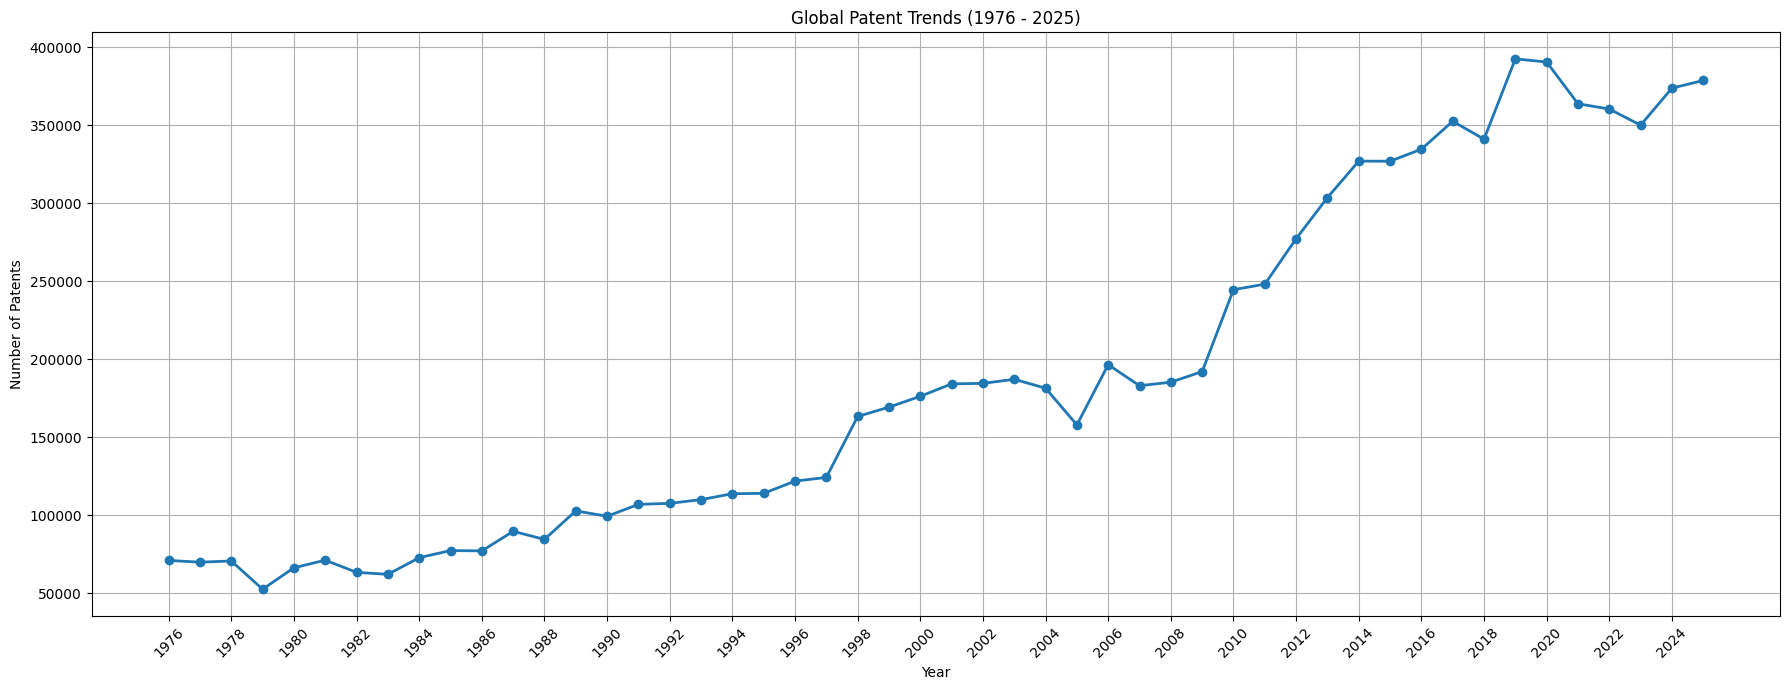

In [27]:
# ==================================
# FULL PATENT TREND VISUALIZATION
# ==================================

import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(18,7))

# Plot line
plt.plot(
    trends['year'],
    trends['total_patents'],
    marker='o',
    linewidth=2
)

# Show all years
plt.xticks(
    range(
        int(trends['year'].min()),
        int(trends['year'].max()) + 1,
        2
    ),
    rotation=45
)

# Labels
plt.xlabel("Year")
plt.ylabel("Number of Patents")
plt.title("Global Patent Trends (1976 - 2025)")

# Grid
plt.grid(True)

# Tight layout
plt.tight_layout()

plt.show()

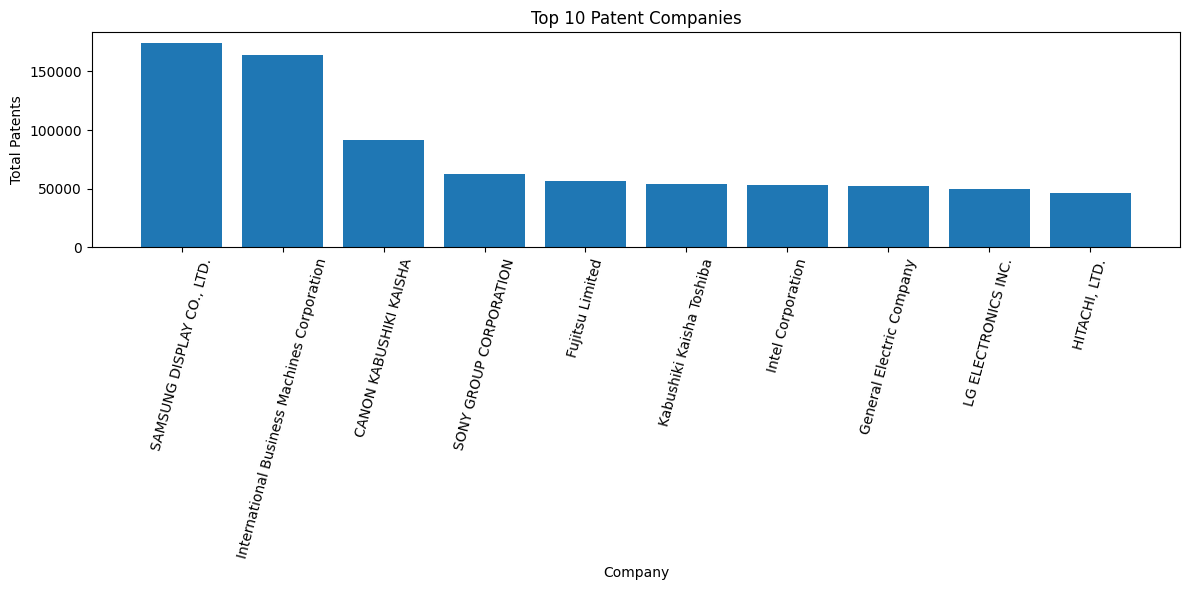

In [28]:
# ==================================
# TOP COMPANIES BAR CHART
# ==================================

plt.figure(figsize=(12,6))

plt.bar(
    top_companies['name'],
    top_companies['total_patents']
)

plt.xticks(rotation=75)

plt.xlabel("Company")
plt.ylabel("Total Patents")
plt.title("Top 10 Patent Companies")

plt.tight_layout()

plt.show()

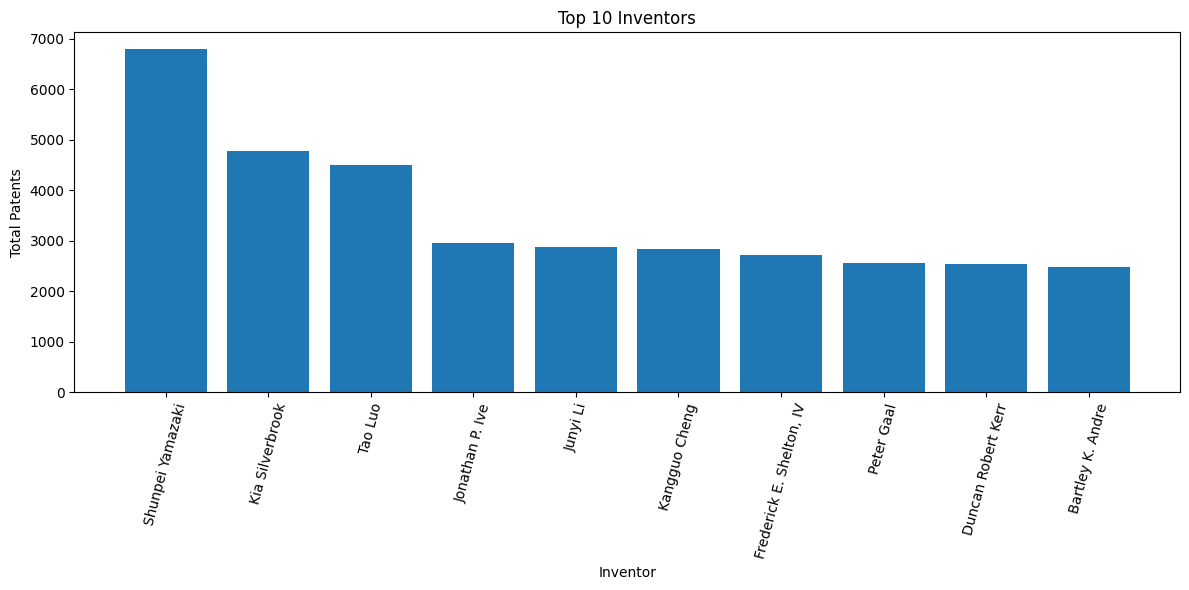

In [29]:
# ==================================
# TOP INVENTORS
# ==================================

plt.figure(figsize=(12,6))

plt.bar(
    top_inventors['name'],
    top_inventors['total_patents']
)

plt.xticks(rotation=75)

plt.xlabel("Inventor")
plt.ylabel("Total Patents")
plt.title("Top 10 Inventors")

plt.tight_layout()

plt.show()

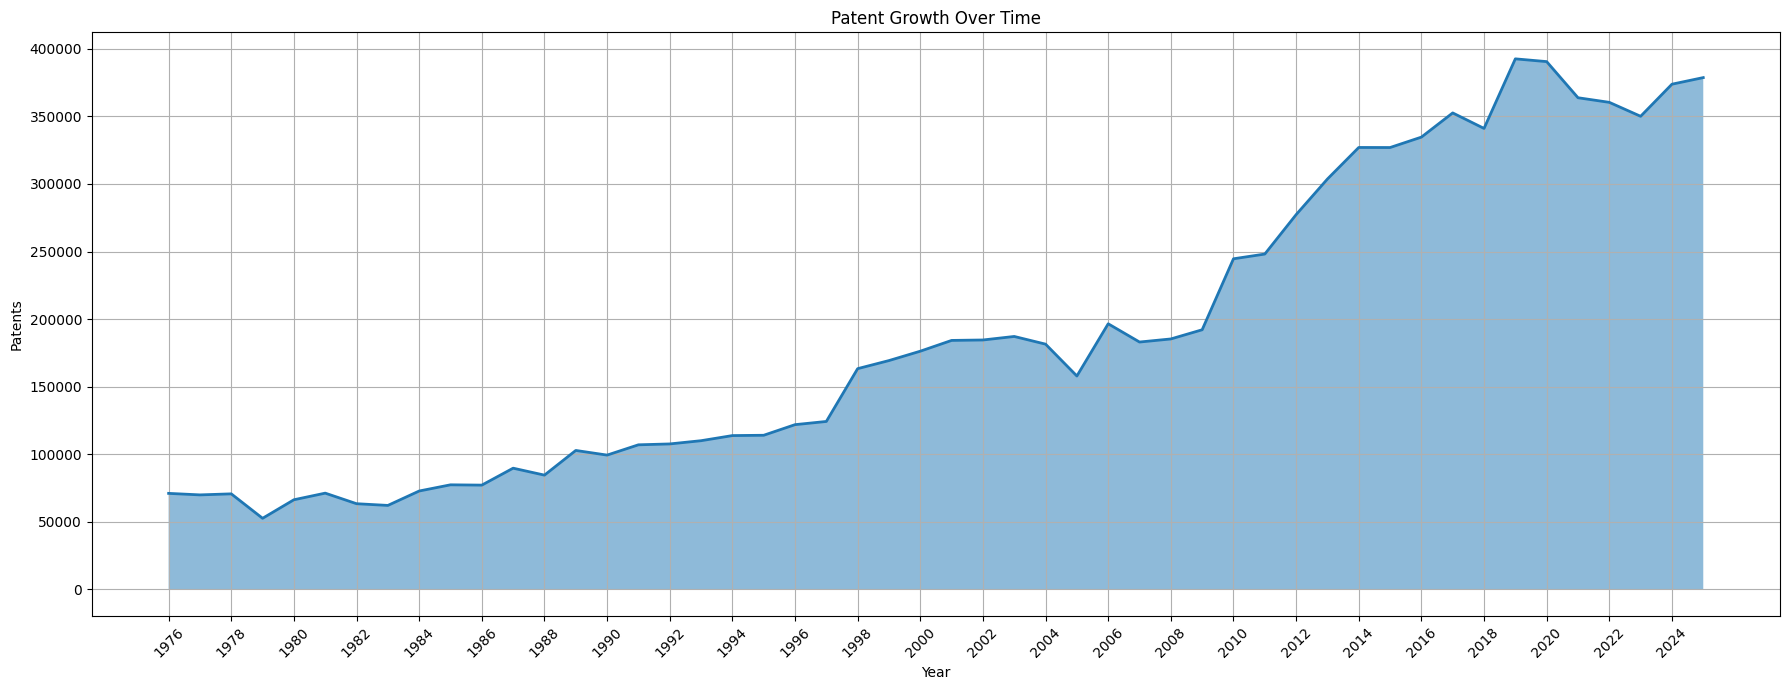

In [30]:
# ==================================
# AREA CHART
# ==================================

plt.figure(figsize=(18,7))

plt.fill_between(
    trends['year'],
    trends['total_patents'],
    alpha=0.5
)

plt.plot(
    trends['year'],
    trends['total_patents'],
    linewidth=2
)

plt.xticks(
    range(
        int(trends['year'].min()),
        int(trends['year'].max()) + 1,
        2
    ),
    rotation=45
)

plt.xlabel("Year")
plt.ylabel("Patents")
plt.title("Patent Growth Over Time")

plt.grid(True)

plt.tight_layout()

plt.show()

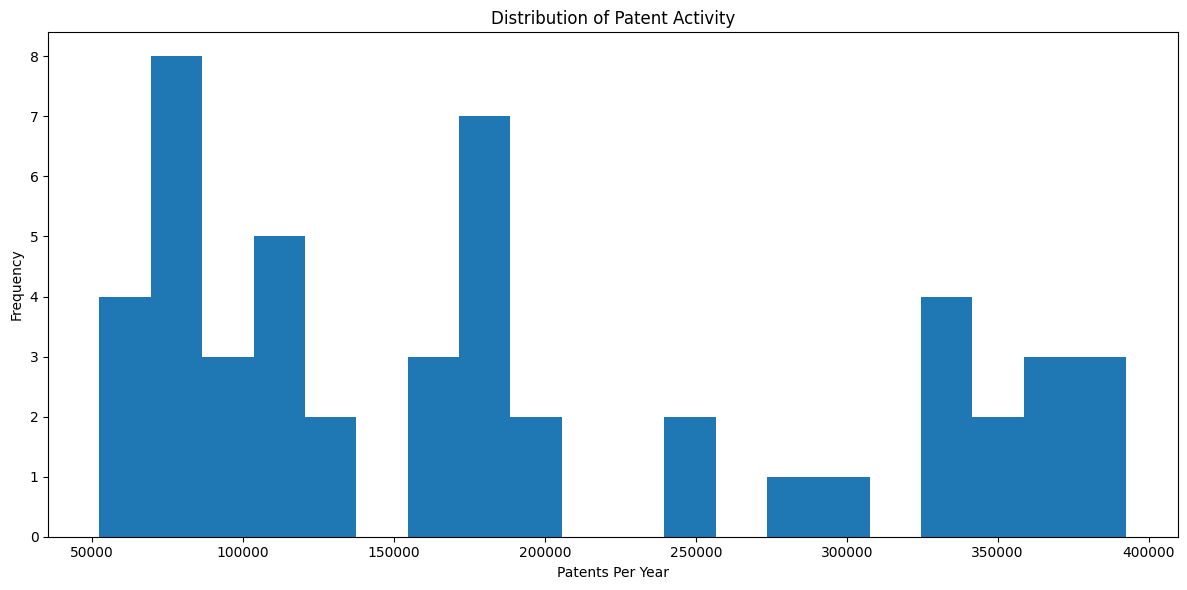

In [36]:
# ==================================
# HISTOGRAM
# ==================================

plt.figure(figsize=(12,6))

plt.hist(
    trends['total_patents'],
    bins=20
)

plt.xlabel("Patents Per Year")
plt.ylabel("Frequency")
plt.title("Distribution of Patent Activity")

plt.tight_layout()

plt.show()